In [2]:

import pandas as pd
import numpy as np
import re
import string
!pip install vaderSentiment

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [3]:


true_df = pd.read_csv("/content/True.csv")
fake_df = pd.read_csv("/content/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

df = pd.concat([true_df, fake_df], ignore_index=True)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


In [4]:


def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    text = re.sub(r'\(reuters\)', ' ', text)
    text = re.sub(r'reuters', ' ', text)
    text = re.sub(r'^[A-Z\s]+-\s', ' ', text)

    text = re.sub(r'\b(monday|tuesday|wednesday|thursday|friday|saturday|sunday)\b', ' ', text)
    text = re.sub(r'\b(january|february|march|april|may|june|july|august|'
                  r'september|october|november|december|'
                  r'jan|feb|mar|apr|jun|jul|aug|sep|oct|nov|dec)\b', ' ', text)

    leak_words = [
        "washington", "new york", "said", "told",
        "video", "image", "images", "watch", "breaking"
    ]

    pattern = r'\b(' + '|'.join(leak_words) + r')\b'
    text = re.sub(pattern, ' ', text)

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:


df["title"] = df["title"].apply(clean_text)
df["text"] = df["text"].apply(clean_text)

df["content"] = df["title"] + " " + df["text"]
df = df[["content", "label"]]

X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, C=1, n_jobs=-1)
model.fit(X_train_vec, y_train)

# Evaluation
y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.976837416481069
ROC-AUC: 0.9967731840038685


In [7]:


sentiment_analyzer = SentimentIntensityAnalyzer()

SENSATIONAL_WORDS = {
    "shocking", "unbelievable", "explosive",
    "disaster", "nightmare", "chaos",
    "outrageous", "incredible",
    "terrifying", "horrifying"
}

HYPERBOLE_WORDS = {
    "always", "never", "everyone", "no one",
    "worst ever", "best ever",
    "guaranteed", "totally"
}

CLICKBAIT_PATTERNS = [
    r"you won'?t believe",
    r"what happens next",
    r"number \d+",
    r"this is what happened",
    r"will blow your mind"
]


def sensational_score(text):
    words = re.findall(r'\w+', text.lower())
    count = sum(word in SENSATIONAL_WORDS for word in words)
    return round((count / max(len(words), 1)) * 100, 2)


def clickbait_score(text):
    return sum(bool(re.search(p, text.lower())) for p in CLICKBAIT_PATTERNS)


def exaggeration_score(text):
    lower = text.lower()
    count = sum(phrase in lower for phrase in HYPERBOLE_WORDS)
    superlatives = re.findall(r'\b\w+est\b', lower)
    return count + len(superlatives)


def visual_emphasis_score(text):
    words = text.split()
    caps = sum(word.isupper() and len(word) > 2 for word in words)
    punct = text.count("!") + text.count("?")
    return caps + punct


def emotional_intensity_score(text):
    return round(abs(sentiment_analyzer.polarity_scores(text)["compound"]), 2)

In [8]:


def analyze_article(text):

    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    prob_real = model.predict_proba(vec)[0][1]
    credibility = round(prob_real * 100, 2)

    # Style metrics
    sens = sensational_score(text)
    click = clickbait_score(text)
    exaggeration = exaggeration_score(text)
    visual = visual_emphasis_score(text)
    emotional = emotional_intensity_score(text)

    print("\n==========================================")
    print("CREDIBILITY ANALYSIS REPORT")
    print("==========================================\n")

    print(f"Overall Credibility Score: {credibility}/100")
    print("Model Prediction:",
          "Likely REAL news" if credibility >= 50 else "Likely FAKE news")

    print("\n--- Writing Style Analysis ---\n")

    print(f"Sensational Language Score: {sens}")
    print("→ Measures use of dramatic or emotionally charged words.\n")

    print(f"Clickbait Framing Score: {click}")
    print("→ Detects manipulative headline patterns.\n")

    print(f"Exaggeration (Hyperbole) Score: {exaggeration}")
    print("→ Counts extreme claims or absolute wording.\n")

    print(f"Visual Emphasis Score: {visual}")
    print("→ Detects ALL CAPS words and excessive punctuation.\n")

    print(f"Emotional Intensity Score: {emotional}")
    print("→ Measures emotional polarity strength (0 = neutral, 1 = extreme).\n")

    print("==========================================\n")

In [9]:
sample_text = """
YOU WON'T BELIEVE what happened next!!!
This shocking disaster completely destroyed everything.
"""

analyze_article(sample_text)


CREDIBILITY ANALYSIS REPORT

Overall Credibility Score: 4.49/100
Model Prediction: Likely FAKE news

--- Writing Style Analysis ---

Sensational Language Score: 15.38
→ Measures use of dramatic or emotionally charged words.

Clickbait Framing Score: 1
→ Detects manipulative headline patterns.

Exaggeration (Hyperbole) Score: 0
→ Counts extreme claims or absolute wording.

Visual Emphasis Score: 6
→ Detects ALL CAPS words and excessive punctuation.

Emotional Intensity Score: 0.91
→ Measures emotional polarity strength (0 = neutral, 1 = extreme).




Confusion Matrix:

[[4579  117]
 [  91 4193]]


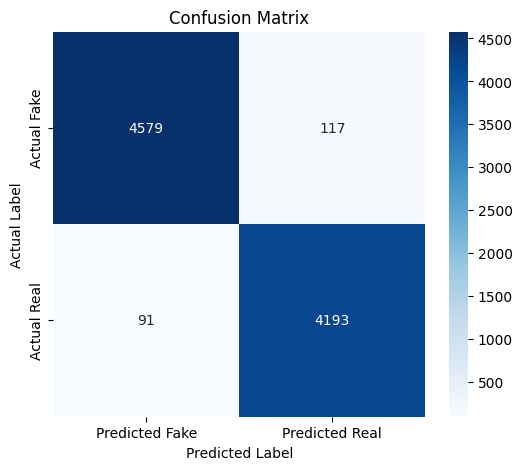

In [10]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [11]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))